In [ ]:
# Data Handling
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving retail_customer_segmentation.csv to retail_customer_segmentation (2).csv


In [ ]:
# Load CSV File
df = pd.read_csv('retail_customer_segmentation.csv')
# Show first 5 rows
df.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment
0,33554,53,100473.211709,63,121.430565,0.817268,66.820403,0.117256,0.023144,77.298393,2.0,Card,Semi-Urban,Occasional
1,9428,54,54730.644845,67,572.552674,3.176551,137.087449,0.261647,0.429054,92.132565,2.0,Wallet,Urban,Occasional
2,200,44,58268.121079,57,266.593896,2.713168,71.796888,0.284785,0.011854,155.194768,1.0,UPI,Rural,Occasional
3,12448,54,64829.795654,40,691.452358,5.553977,105.501185,0.104832,0.399686,113.917756,0.0,Wallet,Rural,High_Value
4,39490,28,27431.467873,15,832.664792,1.348389,354.568534,0.409204,0.039517,50.123656,1.0,Card,Semi-Urban,Occasional


In [ ]:
# Dataset shape
print('Dataset Shape:', df.shape)
# Column names
print('\nColumns:\n', df.columns)
# Dataset info
print('\nDataset Info:\n')
df.info()

Dataset Shape: (50000, 14)

Columns:
 Index(['customer_id', 'age', 'annual_income', 'months_active',
       'avg_monthly_spend', 'purchase_frequency', 'avg_order_value',
       'discount_usage_rate', 'return_rate', 'browsing_time_minutes',
       'support_interactions', 'payment_method', 'region', 'customer_segment'],
      dtype='object')

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            50000 non-null  int64  
 1   age                    50000 non-null  int64  
 2   annual_income          46925 non-null  float64
 3   months_active          50000 non-null  int64  
 4   avg_monthly_spend      47480 non-null  float64
 5   purchase_frequency     48021 non-null  float64
 6   avg_order_value        50000 non-null  float64
 7   discount_usage_rate    47451 non-null  float64
 8   return_r

In [ ]:
# Missing values
print(df.isnull().sum())

customer_id                 0
age                         0
annual_income            3075
months_active               0
avg_monthly_spend        2520
purchase_frequency       1979
avg_order_value             0
discount_usage_rate      2549
return_rate              2487
browsing_time_minutes    3934
support_interactions     1988
payment_method              0
region                      0
customer_segment            0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)
print('New Shape:', df.shape)

New Shape: (50000, 14)


In [ ]:
# Summary statistics

df.describe()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions
count,50000.000000,50000.000000,46925.000000,50000.000000,47480.000000,48021.000000,50000.000000,47451.000000,47513.000000,46066.000000,48012.000000
mean,25000.500000,44.002820,44542.620904,36.477480,337.294238,4.910841,77.375915,0.284358,0.148964,61.781329,1.494606
std,14433.901067,15.269871,30537.946035,20.787197,204.627095,3.416115,70.531793,0.159236,0.110508,41.743394,1.221280
min,1.000000,18.000000,2946.317892,1.000000,8.072298,0.017013,0.940393,0.000534,0.000050,0.236109,0.000000
25%,12500.750000,31.000000,24373.244554,18.000000,192.074544,2.456867,32.018468,0.160497,0.063938,31.082283,1.000000
50%,25000.500000,44.000000,36787.730010,36.000000,297.477404,4.158673,56.600351,0.262591,0.123628,52.679175,1.000000
75%,37500.250000,57.000000,55497.245522,55.000000,439.112361,6.526903,98.832037,0.387640,0.209612,82.549571,2.000000
max,50000.000000,70.000000,530788.317921,72.000000,3026.342238,67.682528,1289.427328,0.934655,0.830395,406.813006,9.000000


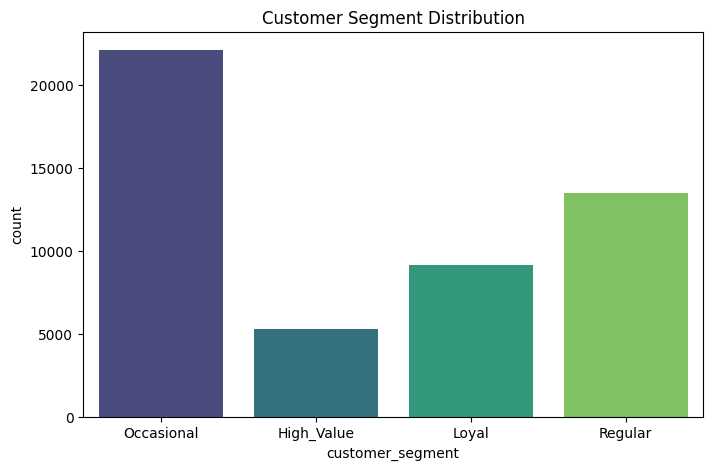

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='customer_segment', data=df, palette='viridis')
plt.title('Customer Segment Distribution')
plt.show()


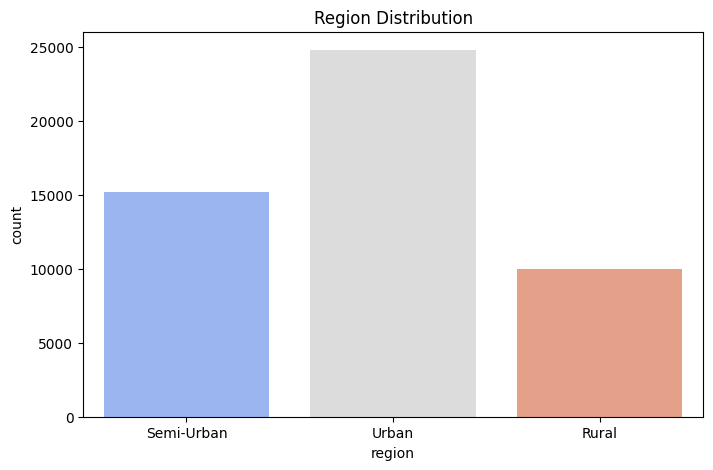

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='region', data=df, palette='coolwarm')
plt.title('Region Distribution')
plt.show()

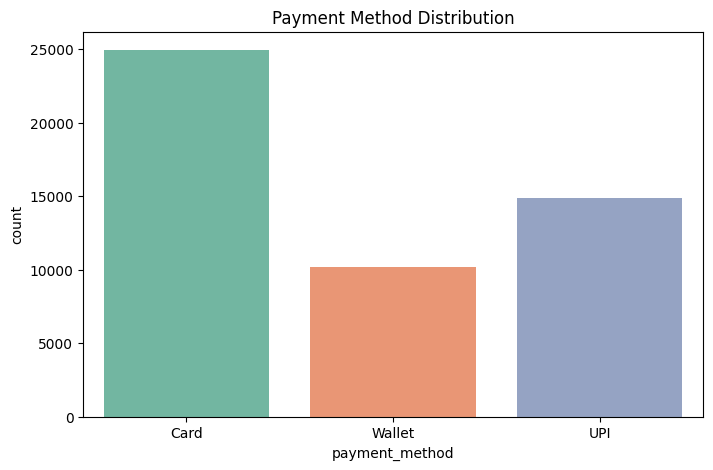

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='payment_method', data=df, palette='Set2')
plt.title('Payment Method Distribution')
plt.show()

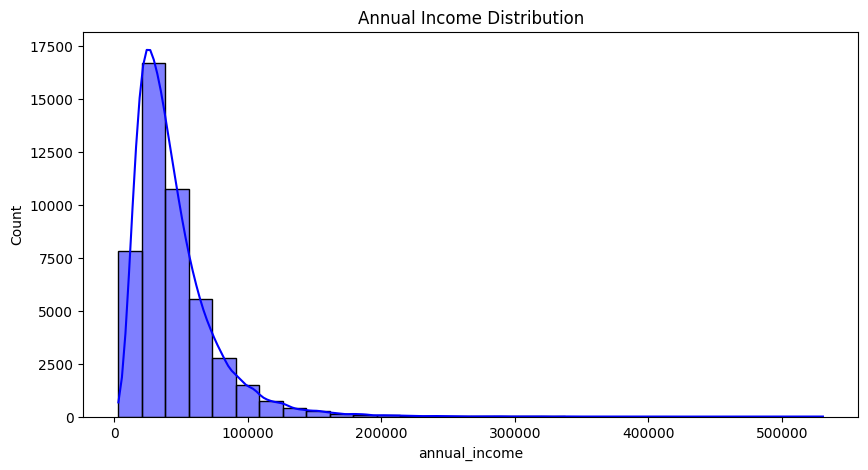

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['annual_income'], bins=30, kde=True, color='blue')
plt.title('Annual Income Distribution')
plt.show()

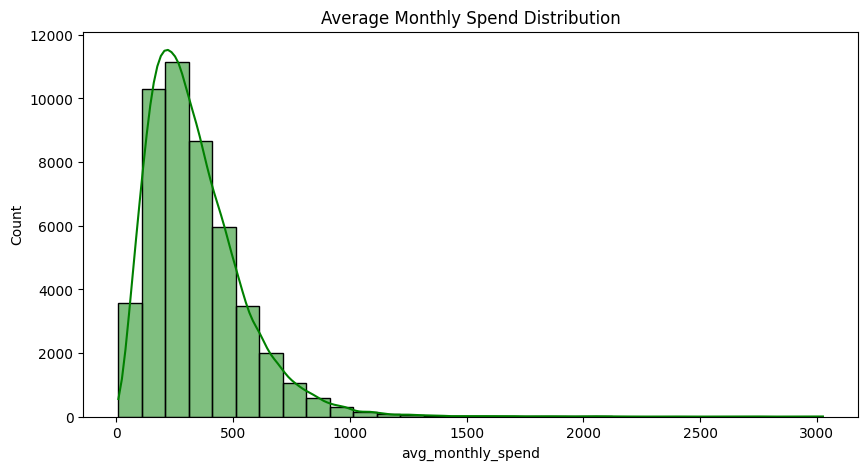

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['avg_monthly_spend'], bins=30, kde=True, color='green')
plt.title('Average Monthly Spend Distribution')
plt.show()

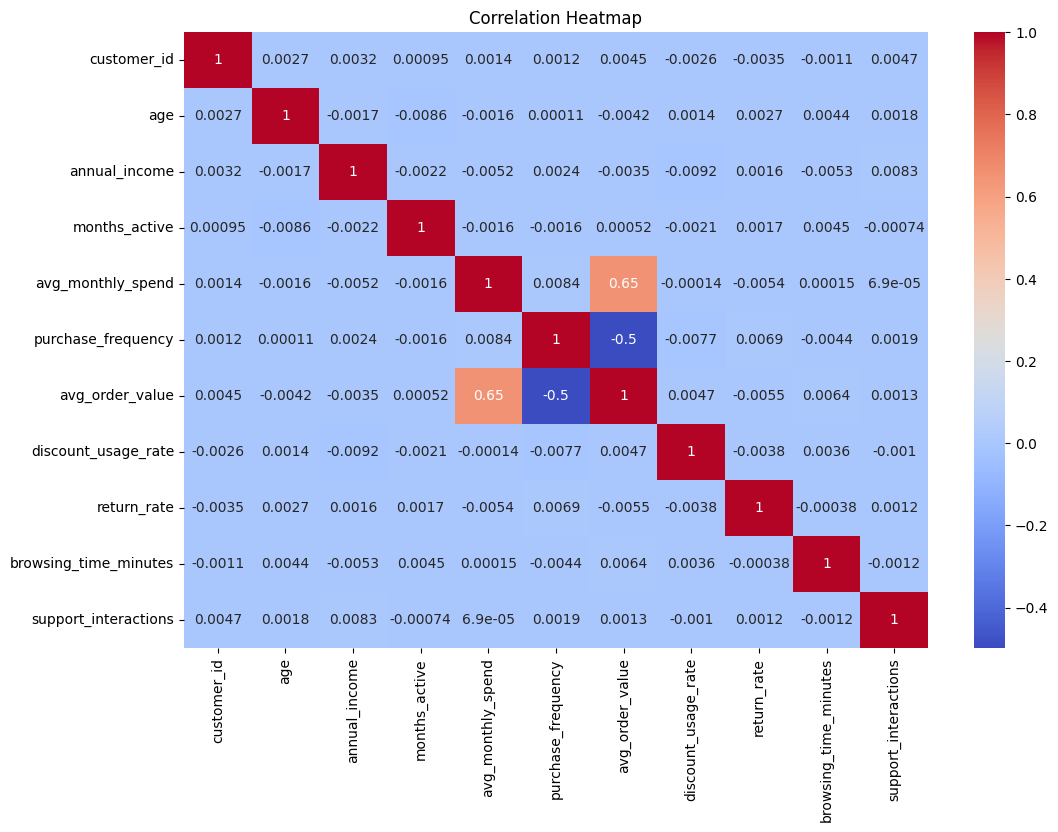

In [ ]:
plt.figure(figsize=(12,8))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Create Customer Lifetime Value (CLV)
df['customer_lifetime_value'] = (
    df['avg_monthly_spend'] * df['months_active']
)
# Create spending score
df['spending_score'] = (
    df['purchase_frequency'] * df['avg_order_value']
)
# Show dataset
df.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment,customer_lifetime_value,spending_score
0,33554,53,100473.211709,63,121.430565,0.817268,66.820403,0.117256,0.023144,77.298393,2.0,Card,Semi-Urban,Occasional,7650.125599,54.610162
1,9428,54,54730.644845,67,572.552674,3.176551,137.087449,0.261647,0.429054,92.132565,2.0,Wallet,Urban,Occasional,38361.029158,435.465225
2,200,44,58268.121079,57,266.593896,2.713168,71.796888,0.284785,0.011854,155.194768,1.0,UPI,Rural,Occasional,15195.852087,194.797008
3,12448,54,64829.795654,40,691.452358,5.553977,105.501185,0.104832,0.399686,113.917756,0.0,Wallet,Rural,High_Value,27658.094329,585.951173
4,39490,28,27431.467873,15,832.664792,1.348389,354.568534,0.409204,0.039517,50.123656,1.0,Card,Semi-Urban,Occasional,12489.971884,478.096258


In [ ]:
# Encode categorical columns
label_encoder = LabelEncoder()
categorical_columns = ['payment_method', 'region', 'customer_segment']
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])
# Check datase
df.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment,customer_lifetime_value,spending_score
0,33554,53,100473.211709,63,121.430565,0.817268,66.820403,0.117256,0.023144,77.298393,2.0,0,1,2,7650.125599,54.610162
1,9428,54,54730.644845,67,572.552674,3.176551,137.087449,0.261647,0.429054,92.132565,2.0,2,2,2,38361.029158,435.465225
2,200,44,58268.121079,57,266.593896,2.713168,71.796888,0.284785,0.011854,155.194768,1.0,1,0,2,15195.852087,194.797008
3,12448,54,64829.795654,40,691.452358,5.553977,105.501185,0.104832,0.399686,113.917756,0.0,2,0,0,27658.094329,585.951173
4,39490,28,27431.467873,15,832.664792,1.348389,354.568534,0.409204,0.039517,50.123656,1.0,0,1,2,12489.971884,478.096258


In [ ]:
features = [
    'annual_income',
    'avg_monthly_spend',
    'purchase_frequency',
    'avg_order_value',
    'customer_lifetime_value',
    'spending_score'
]
X = df[features]

In [ ]:
X = X.fillna(X.median())
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaling Completed Successfully")

Scaling Completed Successfully


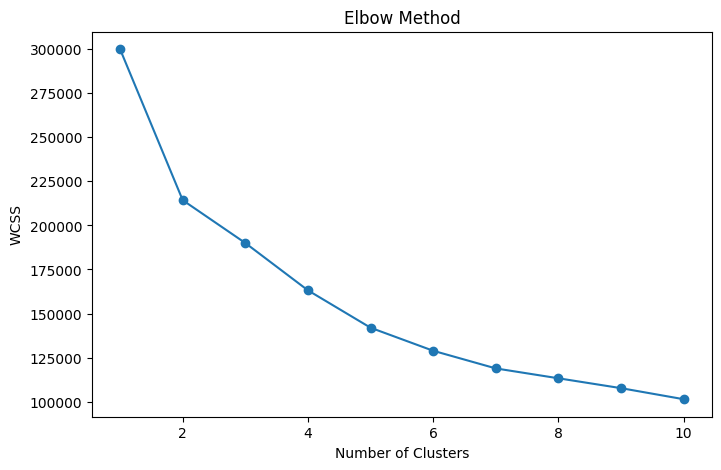

In [ ]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
# Add cluster column
df['Cluster'] = clusters
# Display first rows
df.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment,customer_lifetime_value,spending_score,Cluster
0,33554,53,100473.211709,63,121.430565,0.817268,66.820403,0.117256,0.023144,77.298393,2.0,0,1,2,7650.125599,54.610162,2
1,9428,54,54730.644845,67,572.552674,3.176551,137.087449,0.261647,0.429054,92.132565,2.0,2,2,2,38361.029158,435.465225,1
2,200,44,58268.121079,57,266.593896,2.713168,71.796888,0.284785,0.011854,155.194768,1.0,1,0,2,15195.852087,194.797008,0
3,12448,54,64829.795654,40,691.452358,5.553977,105.501185,0.104832,0.399686,113.917756,0.0,2,0,0,27658.094329,585.951173,1
4,39490,28,27431.467873,15,832.664792,1.348389,354.568534,0.409204,0.039517,50.123656,1.0,0,1,2,12489.971884,478.096258,1


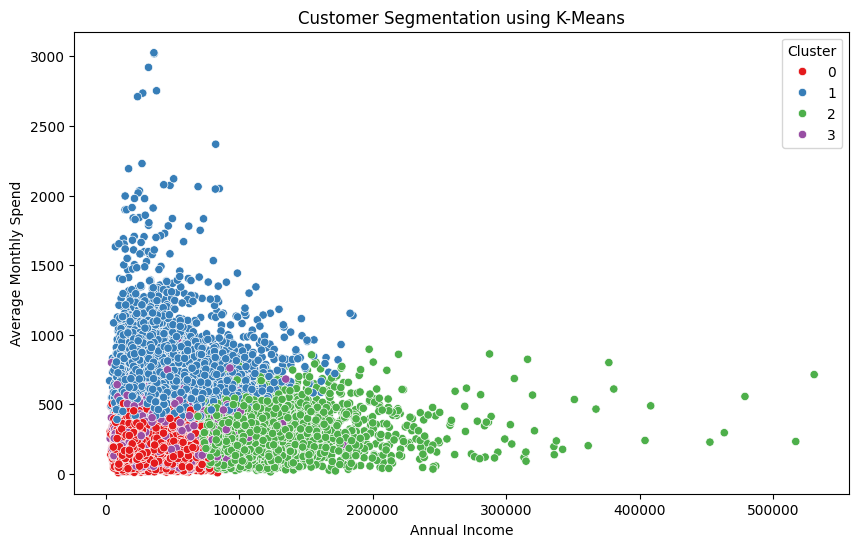

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=df['annual_income'],
    y=df['avg_monthly_spend'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income')
plt.ylabel('Average Monthly Spend')
plt.show()

In [ ]:
score = silhouette_score(X_scaled, clusters)
print('Silhouette Score:', score)

Silhouette Score: 0.24960388196173303


In [ ]:
# Predict customer segment
y = df['customer_segment']
# Features
X_model = df.drop(['customer_segment', 'customer_id'], axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.2,
    random_state=42
)
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

# Classification Report
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))

Accuracy: 0.7469

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.76      0.80      1049
           1       0.86      0.79      0.82      1885
           2       0.75      0.84      0.79      4347
           3       0.63      0.56      0.59      2719

    accuracy                           0.75     10000
   macro avg       0.77      0.74      0.75     10000
weighted avg       0.75      0.75      0.74     10000



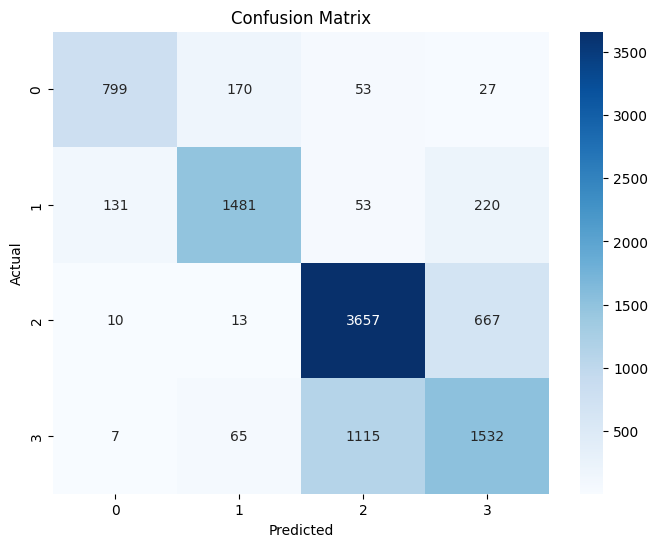

In [ ]:
plt.figure(figsize=(8,6))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

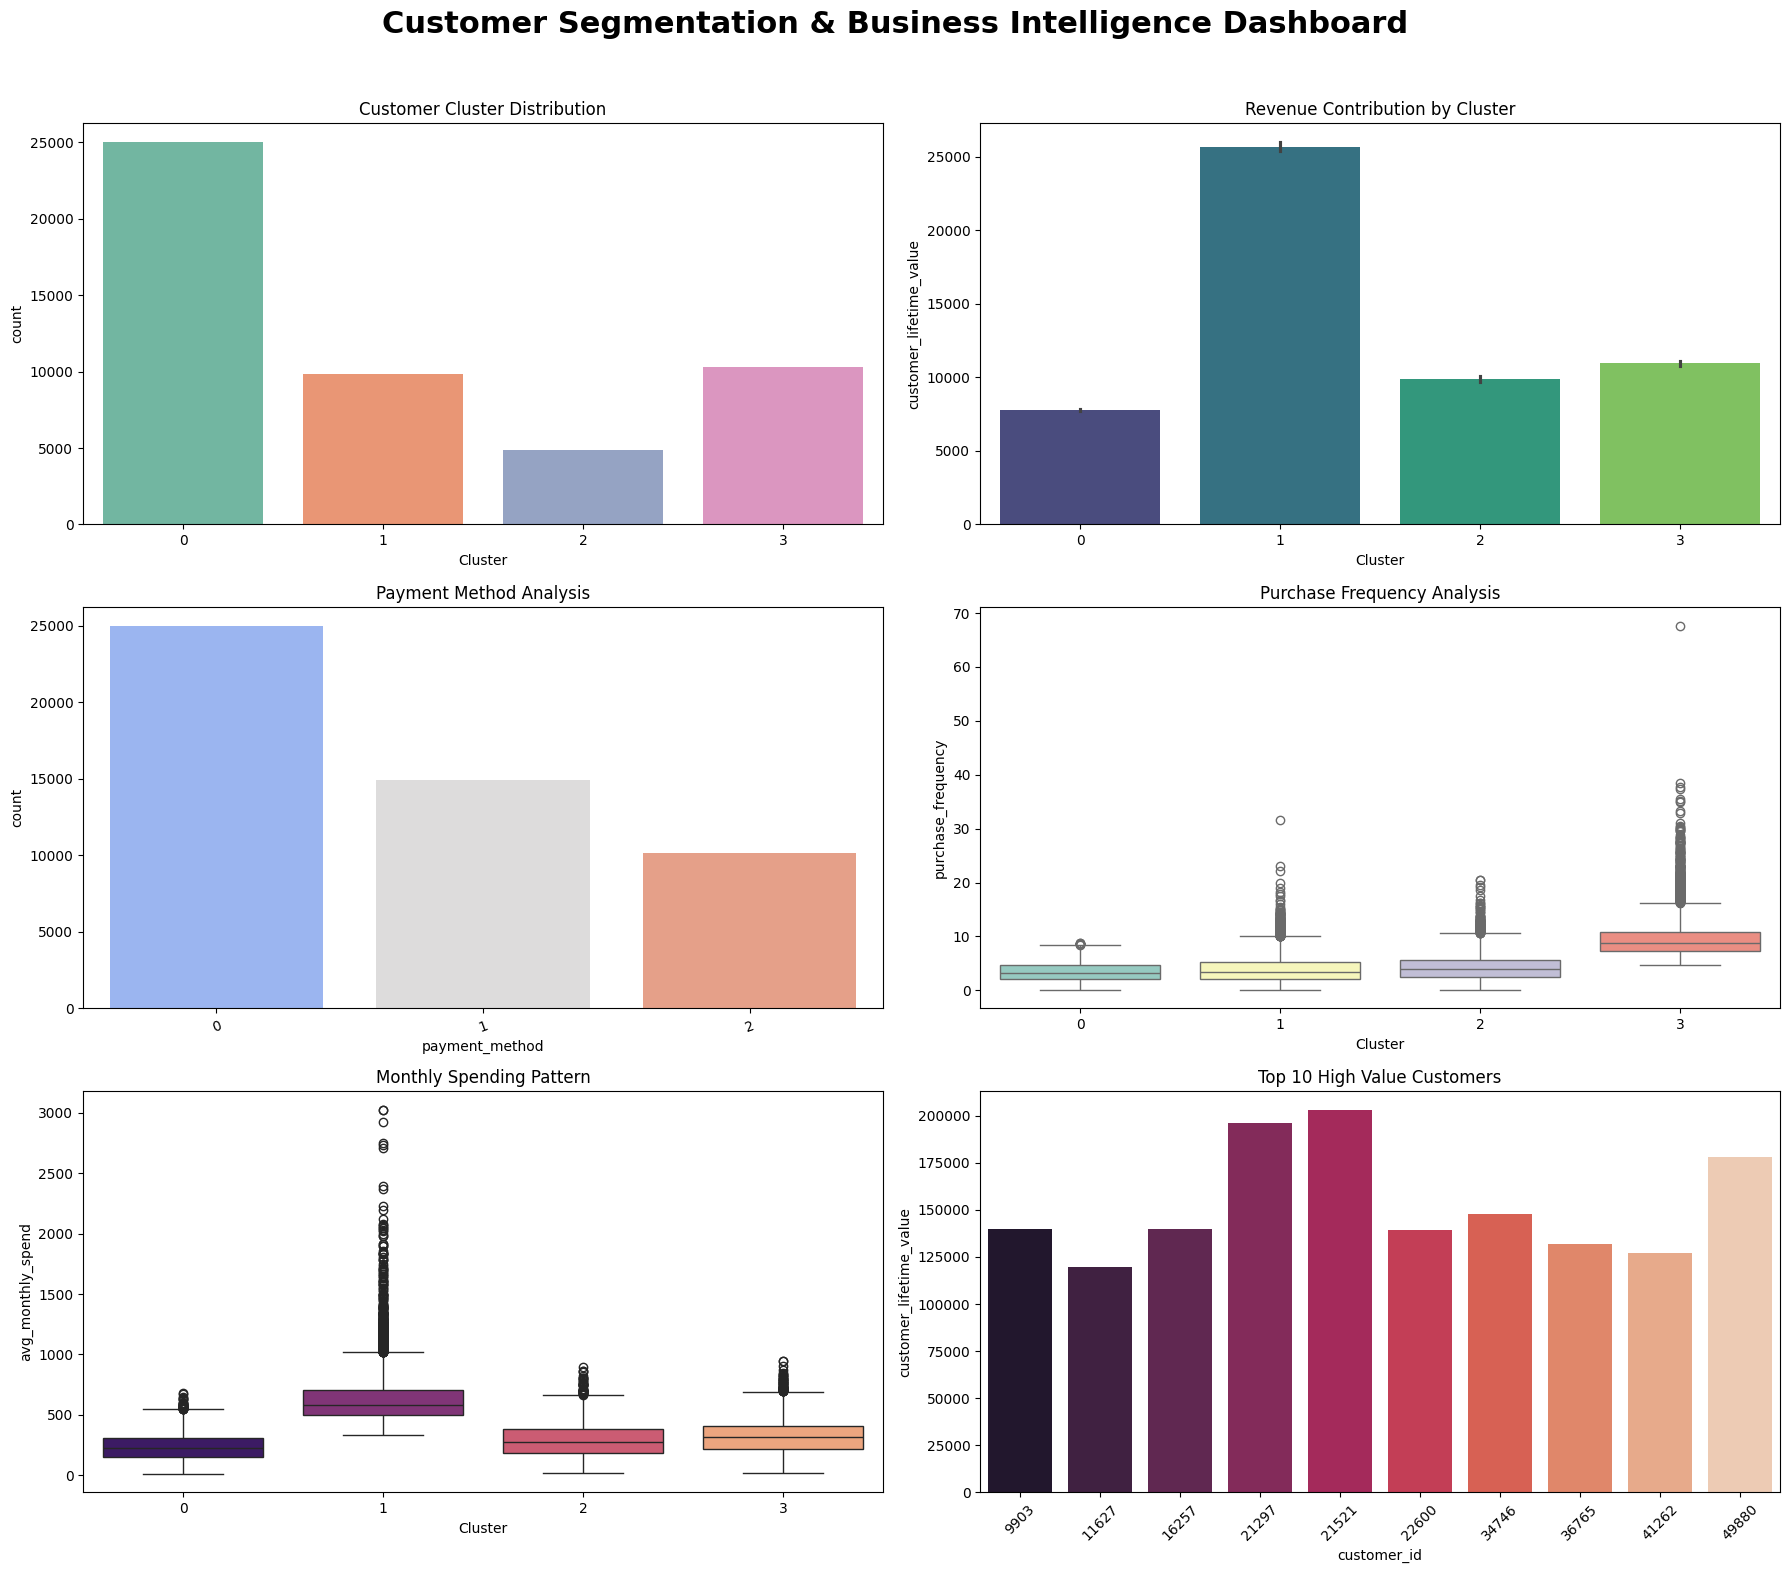

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle('Customer Segmentation & Business Intelligence Dashboard',
             fontsize=22,
             fontweight='bold')
# 1. Customer Cluster Distribution
sns.countplot(x='Cluster', data=df, palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Customer Cluster Distribution')
# 2. Revenue by Cluster
sns.barplot(x='Cluster',
            y='customer_lifetime_value',
            data=df,
            palette='viridis',
            ax=axes[0,1])
axes[0,1].set_title('Revenue Contribution by Cluster')
# 3. Payment Method Distribution
sns.countplot(x='payment_method',
              data=df,
              palette='coolwarm',
              ax=axes[1,0])
axes[1,0].set_title('Payment Method Analysis')
axes[1,0].tick_params(axis='x', rotation=20)
# 4. Purchase Frequency by Cluster
sns.boxplot(x='Cluster',
            y='purchase_frequency',
            data=df,
            palette='Set3',
            ax=axes[1,1])
axes[1,1].set_title('Purchase Frequency Analysis')
# 5. Monthly Spending Pattern
sns.boxplot(x='Cluster',
            y='avg_monthly_spend',
            data=df,
            palette='magma',
            ax=axes[2,0])
axes[2,0].set_title('Monthly Spending Pattern')
# 6. Top Customers
top_customers = df.sort_values(
    by='customer_lifetime_value',
    ascending=False
).head(10)

sns.barplot(x=top_customers['customer_id'],
            y=top_customers['customer_lifetime_value'],
            palette='rocket',
            ax=axes[2,1])

axes[2,1].set_title('Top 10 High Value Customers')
axes[2,1].tick_params(axis='x', rotation=45)
# Dashboard Layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

***FULL SCREEN OUTPUT FOR DICISION MAKEING***

---



---


https://colab.research.google.com/drive/13_eKcfikOOjcfHavT5rYHzCNANzv0XUF#scrollTo=GlZRO-0TTuMP&fullscreenOutput=true

In [ ]:
print('BUSINESS INSIGHTS')
print('----------------------')
print('1. High-value customers can be targeted with premium offers.')
print('2. Customers with high browsing time but low purchases may need remarketing.')
print('3. Frequent buyers can be rewarded through loyalty programs.')
print('4. Different customer clusters help in personalized marketing.')
df.to_csv('customer_segmentation_output.csv', index=False)
print('File Saved Successfully')

BUSINESS INSIGHTS
----------------------
1. High-value customers can be targeted with premium offers.
2. Customers with high browsing time but low purchases may need remarketing.
3. Frequent buyers can be rewarded through loyalty programs.
4. Different customer clusters help in personalized marketing.
File Saved Successfully
